In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [9]:
# Make grid
b_a1 = 2
t1 = 10
d_a1 = 3.8*10**(-4)
a1_0 = 100
runs = 100

def comp_MI(param, cv_b_E,cv_g_ME, cv_b_c1 = 0):

    params = np.random.lognormal(mean = np.log(param), sigma = 0.1*np.log(param), size = runs)

    # choose which parameter to vary
    run_data = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(params)/8))(delayed(sum_sim)(b_a1 = param, noise_cv = [cv_b_E,cv_b_c1,cv_g_ME,0,0,0])
                                                    for param in params))
    
    MI_data = np.zeros(run_data.shape[1])
    for i in range(run_data.shape[1]):
        MI_data[i] = calc_MI(run_data[:,1],run_data[:,i]) # 0 = a1_0, 1 = b_a1
        
    return  np.array(MI_data, dtype=object)

In [10]:
# generate 2 2d grids for the b_E & g_ME bounds
nx, ny = 10, 10
cv_b_E, cv_g_ME = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, ny))

v_comp_MI = np.vectorize(comp_MI)
MI_data_grid = v_comp_MI(b_a1,cv_b_E,cv_g_ME)

# function to slice data by parameters
extract_stats = np.vectorize(lambda x,stat: x[stat])

In [12]:
extract_stats(MI_data_grid,i).shape

(10, 10)

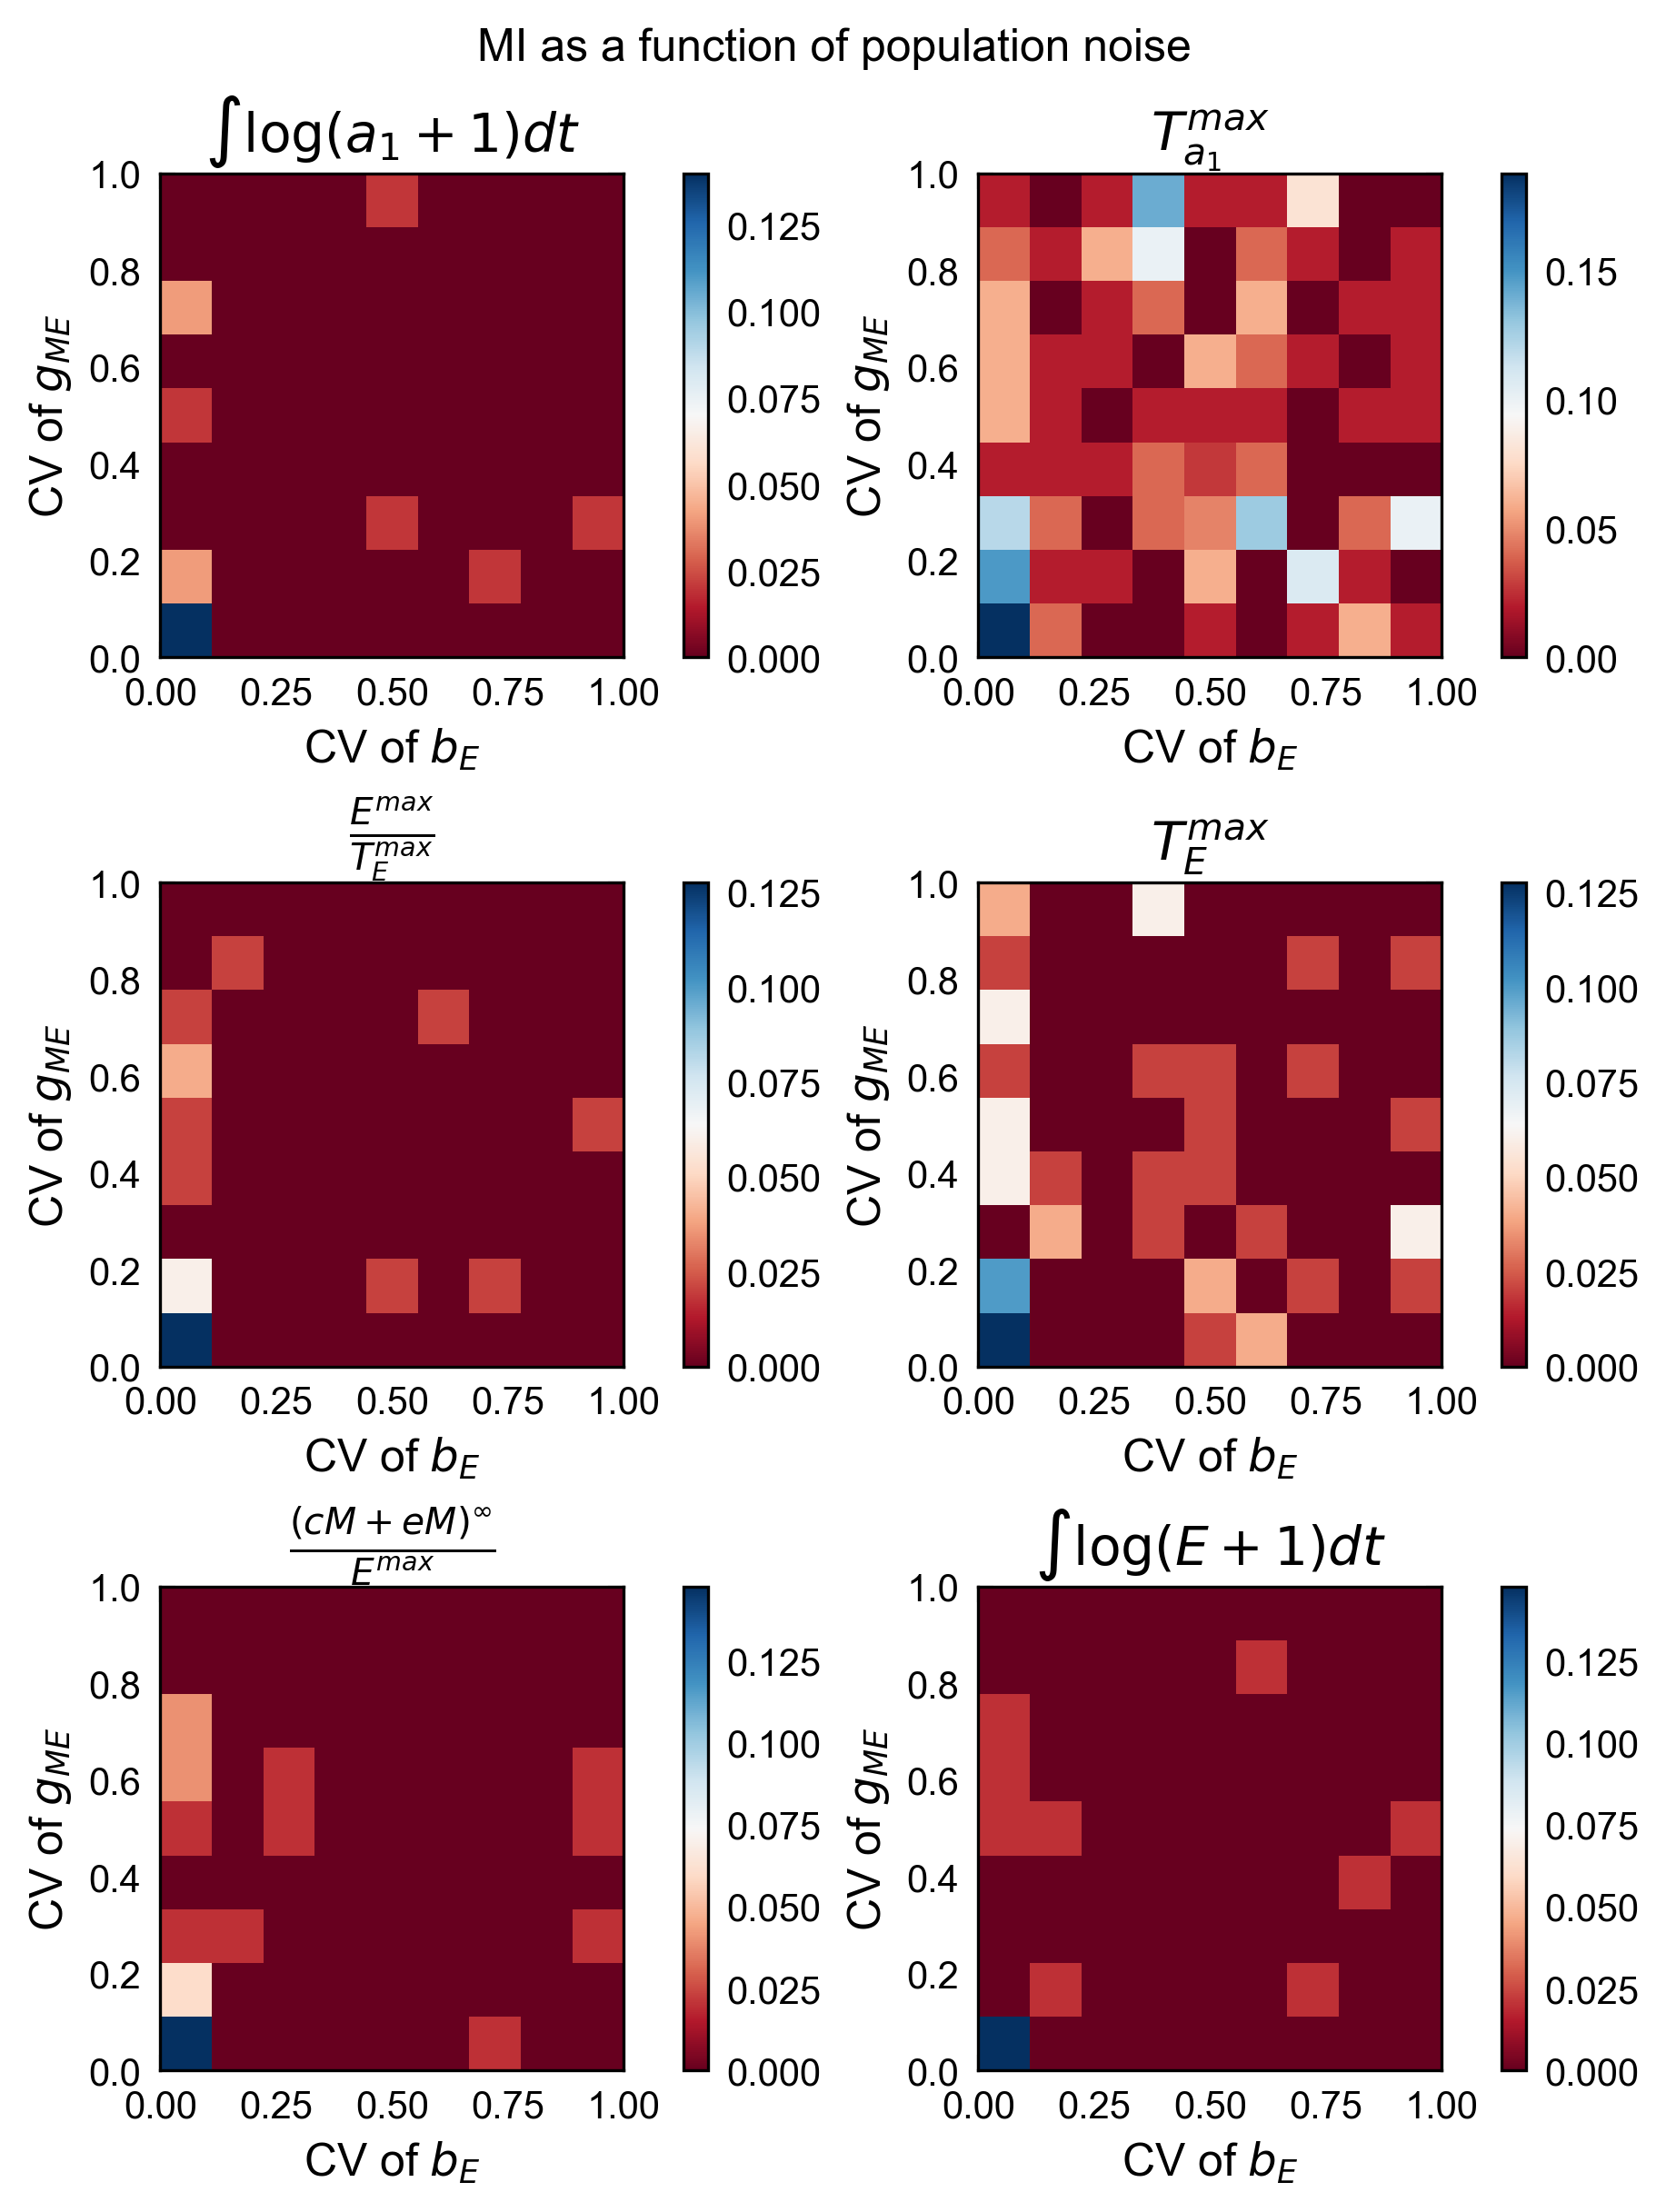

In [14]:
# plot heat maps
fig_b_a1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout = True, figsize = (6,8))
i = 4

for ax, val in zip(axs.flat,stat_names[i:]):
    z = extract_stats(MI_data_grid,i)
    
    z = z[:-1, :-1]
    z_min, z_max = np.abs(z).min(), np.abs(z).max()

    cs = ax.pcolormesh(cv_b_E, cv_g_ME, z, cmap='RdBu', vmin=z_min, vmax=z_max)
    
    ax.set_title(val)
    # set the limits of the plot to the limits of the data
    ax.axis([cv_g_ME.min(), cv_g_ME.max(), cv_g_ME.min(), cv_g_ME.max()])
    ax.set(xlabel=r'CV of $b_E$', ylabel=r'CV of $g_{ME}$')
    fig_b_a1.colorbar(cs, ax=ax)
        
    i += 1
    
fig_b_a1.suptitle('MI as a function of population noise')
fig_b_a1.savefig('MI-vs_noise_b_a1.pdf', dpi=300, bbox_inches="tight")

